# Collide2v challenges: Introduction

This notebook gives a basic introduction to the COLLIDE2V (COmprehensive Lhc coLlision Dataset for Foundation model dEvelopment) open-access high energy physics dataset. There are three hackathon challenges that use this dataset: 

-  Challenge 1: Di-Higgs (HH→4b vs. QCD) discrimination for trigger systems
-   Challenge 2: Collider Data Foundation Model Pre-training and Online Adaptation
-   Challenge 3: Robust Tagging and Self-adapting Trigger Systems Under Changing Detector Conditions

For the purposes of this hackathon we have created subsets of the original 750 million event dataset for use in each challenge. Each subset contains data from physics processes and variables related to that particular challenge. The data is stored as `parquet` files (in subdirectories per process) and organized into training and evaluation datasets. 

```bash
#location of each dataset:
#Challenge 1:
/hack-data/C1_HH4b/train/
/hack-data/C1_HH4b/eval/

#Challenge 2:
/hack-data/C5_foundation_model/train/
/hack-data/C5_foundation_model/eval/

#Challenge 3:
/hack-data/C9_robust_tagging/train/
/hack-data/C9_robust_tagging/eval/
```

This introductory notebook shows how to load these datasets and make a basic model. It uses a small subset of the Challenge 1 data for demonstration purposes, and is based on [Chris Brown's original notebook](https://github.com/Chriisbrown/FastML_tutorial/blob/main/ML_LHC_tutorial.ipynb). 

**Please note:** This example is in pytorch, but if you would rather use tensorflow/keras the [original notebook](https://github.com/Chriisbrown/FastML_tutorial/blob/main/ML_LHC_tutorial.ipynb) does the same exercise using those packages instead. The dataloading in that notebook should be replaced with the hackathon-specific example here if you use it. A copy of that notebook is included for reference in this gitrepo for convenience. 

## Getting Started

In this tutorial, we explore a realistic LHC dataset composed of a **signal sample**: di-Higgs production

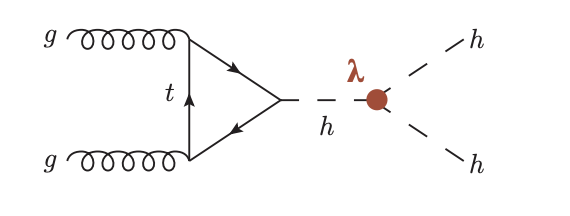

and several high cross-section **background processes** that dominate LHC datasets:

- **QCD multi-jet production**  
- **Top quark pair production** with fully hadronic decays  
- **W boson production** with hadronic decays  

Our goal is to train machine learning models to classify these processes using **all reconstructed particles in each event**.  

Each particle comes with a set of features, including **kinematics, particle ID, and displacement from the primary vertex**. Consequently, the input tensors for our models have shape:

$$
[N_\text{events}, N_\text{particles}, N_\text{particle features}]
$$

We will train and compare a few types of models:

---

### 1. Classic MLP

Uses flattened inputs for all particles in an event.  



### 2. DeepSet

This architecture introduces an **inductive bias that respects permutation symmetry**, meaning the output is invariant to the order of particles in the event.  

Each particle is first embedded individually through a shared function $\phi$:

$$
h_i = \phi(x_i), \quad i = 1, \dots, N_\text{particles}
$$

These embeddings are then **aggregated using a permutation-invariant operation**, typically summation, mean, or max:

$$
H = \rho\Big( \sum_{i=1}^{N_\text{particles}} h_i \Big)
$$

where $\rho$ is a function (often a small feed-forward network) that maps the aggregated embedding to the output, e.g., class probabilities.  

Throughout this tutorial, we justify architectural choices using principles from learning theory and provide references to relevant papers where appropriate.

In [ ]:
#first some imports
import glob
from pathlib import Path

import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import pyarrow.parquet as pq
import torch
import torch.nn as nn
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

seed = 0
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

## Load the dataset

This example uses a small chunk of the C1_HH4b data, but all of the collide2v based datasets can be loaded similarly. It contains HH->bbbb signal events, and QCD, W+Jets and TT background events.

In [ ]:
#load 3000 events per process
DATA_ROOT = Path("hack-data/C1_HH4b/train")
N_EVENTS_PER_SAMPLE = 3000   # small subset per process -- bump this up once you trust the pipeline
N_PARTICLES_MAX = 16        # candidates kept per event (truncate/zero-pad), matches the original tutorial
CAND_FIELDS = ["pt", "eta", "phi", "dxy"]

SAMPLES = sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir())
print("Samples found:", SAMPLES)

In [ ]:
# Read in just the first N events of a sample's first train fragment
def read_first_fragment(sample_dir: Path, n_events: int) -> ak.Array:
    frag = sorted(sample_dir.glob(f"{sample_dir.name}_*.parquet"))[0]
    pf = pq.ParquetFile(frag)
    batch = next(pf.iter_batches(batch_size=n_events, columns=["L1T_PUPPIPart", "label"]))
    return ak.from_arrow(batch)

# Reorganize the data into (N_events, N_particles, N_features) padded tensors (not variable length)
def load_physics_dataset_from_pvc(samples, n_events_per_sample=N_EVENTS_PER_SAMPLE,
                                   n_particles_max=N_PARTICLES_MAX, fields=CAND_FIELDS):
    X_parts, y_parts = [], []

    for sample in samples:
        arr = read_first_fragment(DATA_ROOT / sample, n_events_per_sample)
        cands = arr["L1T_PUPPIPart"]
        labels = ak.to_numpy(arr["label"])

        per_field = []
        for f in fields:
            padded = ak.pad_none(cands[f], n_particles_max, clip=True, axis=1)
            per_field.append(ak.to_numpy(ak.fill_none(padded, 0.0)).astype(np.float32))
        # each entry in per_field is (N_events, N_particles) -> stack into (N_events, N_particles, N_features)
        sample_X = np.stack(per_field, axis=-1)

        X_parts.append(sample_X)
        y_parts.append(labels)
        print(f"{sample}: loaded {len(arr)} events, label={labels[0]}")

    X = np.concatenate(X_parts, axis=0).astype(np.float32)
    y = np.concatenate(y_parts, axis=0).astype(np.int64)
    return X, y


X, y = load_physics_dataset_from_pvc(SAMPLES)
print(X.shape, y.shape)  # (N_total_events, N_particles, N_features), (N_total_events,)
print("Class counts:", {int(c): int((y == c).sum()) for c in np.unique(y)})

## Visualize the data

Let's see what is in our data! Our collider events contain collections of objects: particles (`PUPPIPart`), electrons, muons, small radius ("ak4") jets, large radius ("ak8") jets... 

Each of these collections have different numbers of objects. The data stores up to 500 reconstructed particles in an event, but only up to 5 electrons for example.

The `label` object contains different labels based on event type:

- 0 = QCD (QCD_HT250toInf) background
- 1 = HH_4b (the di-Higgs signal)
- 2 = ttbar background (optional) (merges all three: tt_hadronic, tt_semiLeptonic, tt_leptonic)
- 3 = W+jets background (optional) (merges both: WJetsToLNu, WJetsToQQ)

In [ ]:
#let's see all the collections stored in our events
frag = sorted((DATA_ROOT / "HH_4b").glob("HH_4b_*.parquet"))[0]
full = ak.from_arrow(next(pq.ParquetFile(frag).iter_batches(batch_size=5)))
full.fields

Let's go one level deeper and see what is stored in the reconstructed particles `L1_PUPPIPart`: Note this object collection is called `PUPPIPart` - these are the same as `PFPart` in the original notebook, they just include some extra pile-up weights that the `PFPart` collection doesnt have.

In [ ]:
# what is stored in the reconstructed particles `L1_PUPPIPart?
hh4b_frag = read_first_fragment(DATA_ROOT / "HH_4b", 1) #just one event
hh4b_frag["L1T_PUPPIPart"].fields 

In [ ]:
#make a table of these features to see some of their values 
ak.to_dataframe(hh4b_frag["L1T_PUPPIPart"][:5])

Let's use the reconstructed particles to create an event display of one HH->bbbb signal event to visualize what these particles look like within a cylindrical particle detector:

In [ ]:
def plot_event_display(pt, eta, phi, dxy):
    idx = np.argsort(pt)[-10:][::-1]
    eta, phi, pt, dxy = eta[idx], phi[idx], pt[idx], dxy[idx]

    R = 1.0
    d0_scale = 0.1
    x_end = np.sinh(eta)
    y_start = d0_scale * np.cos(phi)
    z_start = d0_scale * np.sin(phi)
    y_end = y_start + R * np.cos(phi)
    z_end = z_start + R * np.sin(phi)

    fig = plt.figure(figsize=(7, 5), dpi=200)
    ax = fig.add_subplot(projection="3d")

    phi_grid = np.linspace(0, 2 * np.pi, 100)
    x_grid = np.linspace(x_end.min() * 1.2, x_end.max() * 1.2, 100)
    Phi, Xg = np.meshgrid(phi_grid, x_grid)
    ax.plot_surface(Xg, R * np.cos(Phi), R * np.sin(Phi), alpha=0.1)

    for i, (xs, ys, zs, xe, ye, ze, et, ph, p) in enumerate(
        zip(np.zeros_like(x_end), y_start, z_start, x_end, y_end, z_end, eta, phi, pt)
    ):
        ax.plot([xs, xe], [ys, ye], [zs, ze])
        if i in (0, 1):
            ax.text(xe, ye, ze, f"[{p:.1f}, {et:.2f}, {ph:.2f}]", fontsize=8)

    ax.scatter(0, 0, 0, color="black", s=1)
    ax.text(0, 0, 0, "PV", color="black", fontsize=5, ha="left", va="bottom")
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
    ax.set_xlabel(r"z ~ sinh($\eta$)")
    ax.set_box_aspect((2, 1, 1))
    plt.tight_layout()
    plt.show()

c0 = hh4b_frag["L1T_PUPPIPart"][0]
plot_event_display(ak.to_numpy(c0["pt"]), ak.to_numpy(c0["eta"]), ak.to_numpy(c0["phi"]), ak.to_numpy(c0["dxy"]))

## Preprocess the data

Let's normalize and preprocess the data and sort it into train and test sets to make some basic models. 

In [ ]:
#preprocess and normalize etc the data
def preprocess_particles(X, pt_index=0, eta_index=1, phi_index=2, d0_index=3, eta_range=(-5.0, 5.0)):
    X_proc = X.copy()

    pt = X_proc[:, :, pt_index]
    pt_logged = np.log(pt + 1.0)
    pt_min, pt_max = pt_logged.min(), pt_logged.max()
    X_proc[:, :, pt_index] = (pt_logged - pt_min) / (pt_max - pt_min + 1e-8)

    eta_min, eta_max = eta_range
    X_proc[:, :, eta_index] = np.clip((X_proc[:, :, eta_index] - eta_min) / (eta_max - eta_min), 0.0, 1.0)

    d0 = X_proc[:, :, d0_index]
    d0_min, d0_max = d0.min(), d0.max()
    X_proc[:, :, d0_index] = (d0 - d0_min) / (d0_max - d0_min + 1e-8)

    phi = X_proc[:, :, phi_index]
    phi_cos, phi_sin = np.cos(phi), np.sin(phi)
    X_proc = np.delete(X_proc, phi_index, axis=2)
    X_proc = np.concatenate([X_proc, phi_cos[..., np.newaxis], phi_sin[..., np.newaxis]], axis=2)
    return X_proc


X_proc = preprocess_particles(X)
print(X_proc.shape)  # (N_events, N_particles, 5) -- pt, eta, dxy, cos(phi), sin(phi)

In [ ]:
#define our train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_proc, y, test_size=0.4, random_state=42, stratify=y, shuffle=True
)
X_test, X_val, y_test, y_val = train_test_split(
    X_test, y_test, test_size=0.2, random_state=42, stratify=y_test, shuffle=True
)
print("train/val/test:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).long()
X_val_t = torch.from_numpy(X_val).float()
y_val_t = torch.from_numpy(y_val).long()
X_test_t = torch.from_numpy(X_test).float()
y_test_t = torch.from_numpy(y_test).long()
n_classes = int(y.max()) + 1

## Train a MLP

Let's train some basic models with our data, starting with an MLP classifier.

In [ ]:
#define our MLP architecture
class MLP(nn.Module):
    def __init__(self, n_particles, n_features, n_classes):
        super().__init__()
        in_dim = n_particles * n_features
        self.body = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_dim, 1024), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(1024, 512), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.1),
        )
        self.embed_head = nn.Sequential(nn.Linear(128, 32), nn.ReLU(), nn.Dropout(0.1))
        self.out = nn.Linear(32, n_classes)

    def embed(self, x):
        return self.embed_head(self.body(x))

    def logits(self, x):
        return self.out(self.embed(x))

    def forward(self, x):
        return torch.softmax(self.logits(x), dim=-1)

In [ ]:
#setup our classifer training
def train_classifier(model, X_train_t, y_train_t, X_val_t, y_val_t, epochs=20, batch_size=64,
                      initial_lr=1e-3, cosine_alpha=1e-4, checkpoint_path="mlp_best_model.pt"):
    """Adam + cosine LR decay (matching Keras's CosineDecay), cross-entropy
    on raw logits, checkpointing the best-val-accuracy epoch"""
    model.to(device)
    dataset = torch.utils.data.TensorDataset(X_train_t, y_train_t)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr, weight_decay=1e-4)
    total_steps = epochs * max(1, len(loader))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=total_steps, eta_min=initial_lr * cosine_alpha
    )
    criterion = nn.CrossEntropyLoss()

    best_val_acc = -1.0
    for epoch in range(epochs):
        model.train()
        train_loss = train_correct = train_seen = 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model.logits(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            scheduler.step()

            train_loss += loss.item() * len(y_batch)
            train_correct += (logits.argmax(dim=-1) == y_batch).sum().item()
            train_seen += len(y_batch)

        model.eval()
        with torch.no_grad():
            val_logits = model.logits(X_val_t.to(device))
            val_loss = criterion(val_logits, y_val_t.to(device)).item()
            val_acc = (val_logits.argmax(dim=-1).cpu() == y_val_t).float().mean().item()

        print(f"Epoch {epoch + 1:2d}  train_loss={train_loss / train_seen:.4f}  "
              f"train_acc={train_correct / train_seen:.3f}  val_loss={val_loss:.4f}  val_acc={val_acc:.3f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), checkpoint_path) #save the model

    print(f"Best val accuracy: {best_val_acc:.3f}  (saved to {checkpoint_path})")
    model.load_state_dict(torch.load(checkpoint_path))
    return model

In [ ]:
#train the MLP
n_particles, n_features = X_train.shape[1], X_train.shape[2]
mlp = MLP(n_particles, n_features, n_classes)
#train and save your model:
mlp = train_classifier(mlp, X_train_t, y_train_t, X_val_t, y_val_t, checkpoint_path="mlp_best_model.pt")

## Train a DeepSet + Evaluate performance

Let's make a more complicated DeepSet network and compare to our MLP. 

In [ ]:
#define our DeepSet architecture and train it using the same train_classifier setup
class DeepSet(nn.Module):
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.phi = nn.Sequential(
            nn.Linear(n_features, 64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, 32), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(32, 16), nn.ReLU(),
        )
        self.rho_body = nn.Sequential(
            nn.Linear(16, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2),
        )
        self.embed_head = nn.Sequential(nn.Linear(128, 32), nn.ReLU())
        self.out = nn.Linear(32, n_classes)

    def embed(self, x):
        pooled = self.phi(x).mean(dim=1)  # (batch, N_particles, 16) -> (batch, 16)
        return self.embed_head(self.rho_body(pooled))

    def logits(self, x):
        return self.out(self.embed(x))

    def forward(self, x):
        return torch.softmax(self.logits(x), dim=-1)


deepset = DeepSet(n_features, n_classes)
#train and save your model 
deepset = train_classifier(deepset, X_train_t, y_train_t, X_val_t, y_val_t, checkpoint_path="deepset_best_model.pt")

In [ ]:
#Evaluate the models and compare the MLP to the DeepSet performance
def evaluate_model(model, X_t, y_t, model_name="Model", batch_size=512):
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(X_t), batch_size):
            logits = model.logits(X_t[i : i + batch_size].to(device))
            preds.append(logits.argmax(dim=-1).cpu().numpy())
    y_pred = np.concatenate(preds)
    y_true = y_t.numpy()

    acc = np.mean(y_pred == y_true)
    print(f"\n=== {model_name} ===")
    print(f"Test Accuracy: {acc:.3f}\n")
    print("Classification Report:")
    print(classification_report(y_true, y_pred, digits=3))
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion Matrix:")
    print(cm)
    return acc, y_pred, cm


mlp_acc, mlp_pred, mlp_cm = evaluate_model(mlp, X_test_t, y_test_t, "MLP")
deepset_acc, deepset_pred, deepset_cm = evaluate_model(deepset, X_test_t, y_test_t, "DeepSet")

## Internal representations

We can take the pre-classifier head embedding of our models and interpret them as internal representations of our data, visualizing them in 2D using PCA

In [ ]:
#grab the embeddings from the models and plot them
def get_embeddings(model, X_t, batch_size=512):
    model.eval()
    embeddings = []
    with torch.no_grad():
        for i in range(0, len(X_t), batch_size):
            embeddings.append(model.embed(X_t[i : i + batch_size].to(device)).cpu().numpy())
    return np.concatenate(embeddings)


def plot_embeddings(embeddings, labels, title):
    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(embeddings)
    plt.figure(figsize=(6, 5))
    for cls in np.unique(labels):
        mask = labels == cls
        plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], label=f"Class {cls}", s=10, alpha=0.3)
    plt.title(title)
    plt.xlabel("PCA 1"); plt.ylabel("PCA 2")
    plt.legend()
    plt.tight_layout()
    plt.show()


mlp_embedding = get_embeddings(mlp, X_test_t)
deepset_embedding = get_embeddings(deepset, X_test_t)
plot_embeddings(mlp_embedding, y_test, "MLP Internal Representations")
plot_embeddings(deepset_embedding, y_test, "DeepSet Internal Representations")

## Saving/loading your trained models

You likely want to save your model weights and architecture for use later, for example copying it onto a different server for quantizing the model or testing FPGA resource utilization ;) Your model weights were already saved in `train_classifier()` above:

```bash
torch.save(model.state_dict(), checkpoint_path)
```
but you also need to be able to load those weights later. You can for example save more information in your checkpoint like:

```bash
torch.save({
    "state_dict": model.state_dict(),
    "n_particles": n_particles, "n_features": n_features, "n_classes": n_classes,
}, checkpoint_path)
```

You can then download your `model.pt` file by right/ctrl clicking on it in the file viewer and choosing "Download". 

You also need to store your architecture: your class model definitions you used for training, namely `MLP()` and `DeepSet()`. You can copy paste those definitions into the notebook you are loading the model in, or you can save them to a little `.py` file and copy that over too.

Later you could load your model again like, for example:

```bash
#don't forget to import/define MLP, DeepSet or this won't work

ckpt = torch.load("/hack-data/checkpoints/mlp_best_model.pt", map_location="cpu")
mlp = MLP(ckpt["n_particles"], ckpt["n_features"], ckpt["n_classes"])
mlp.load_state_dict(ckpt["state_dict"])
mlp.eval()
```